In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pokedex = pd.read_csv('data/modified/viz_pokemon.csv')
pokedex.head()

,ID,Name,Type 1,Type 2,HiddenAbility,Generation,Hp,Attack,Defense,SpecialAttack,...,DamageFromFairy,Ability 1,Ability 2,NoGender,EggGroup1,EggGroup2,IsMega,FightsWon,TotalFights,WinPercentage
0,1,Bulbasaur,Grass,Poison,Chlorophyll,1,45.0,49.0,49.0,65.0,...,0.5,Overgrow,NaN,0,Monster,Grass,0,37,133,0.278195
1,2,Ivysaur,Grass,Poison,Chlorophyll,1,60.0,62.0,63.0,80.0,...,0.5,Overgrow,NaN,0,Monster,Grass,0,46,121,0.380165
2,3,Venusaur,Grass,Poison,Chlorophyll,1,80.0,82.0,83.0,100.0,...,0.5,Overgrow,NaN,0,Monster,Grass,0,89,132,0.674242
3,4,Mega Venusaur,Grass,Poison,NaN,1,80.0,100.0,123.0,122.0,...,0.5,Thick Fat,NaN,0,Monster,Grass,1,70,125,0.560000
4,5,Charmander,Fire,Fire,Solar Power,1,39.0,52.0,43.0,60.0,...,0.5,Blaze,NaN,0,Monster,Dragon,0,55,112,0.491071


In [3]:
combats = pd.read_csv('data/raw_data/combats.csv')
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


## Biến đổi Winner thành binary


In [4]:
combats['Winner'] = np.where(combats['Winner'] == combats['First_pokemon'], 0, 1)
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,1
1,702,701,1
2,191,668,1
3,237,683,1
4,151,231,0


Quy ước được dùng là:

0: Nếu Pokemon ở vị trí First_pokemon thắng.

1: Nếu Pokemon ở vị trí Second_pokemon thắng.

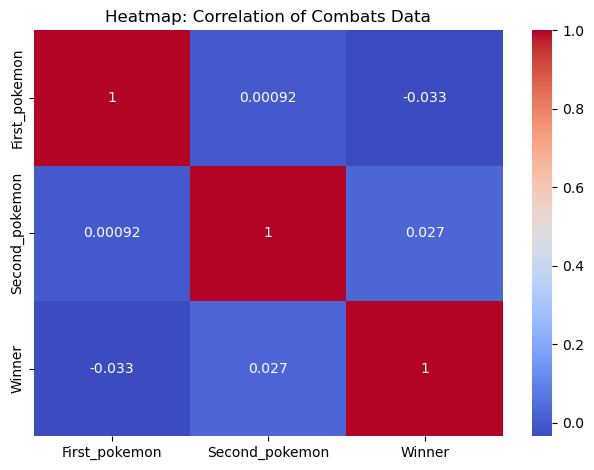

In [5]:
figsize=(9, 6)

combats_corr = combats.corr()
sns.heatmap(combats_corr, annot=True, cmap='coolwarm')
plt.title('Heatmap: Correlation of Combats Data')

plt.tight_layout()
plt.show()

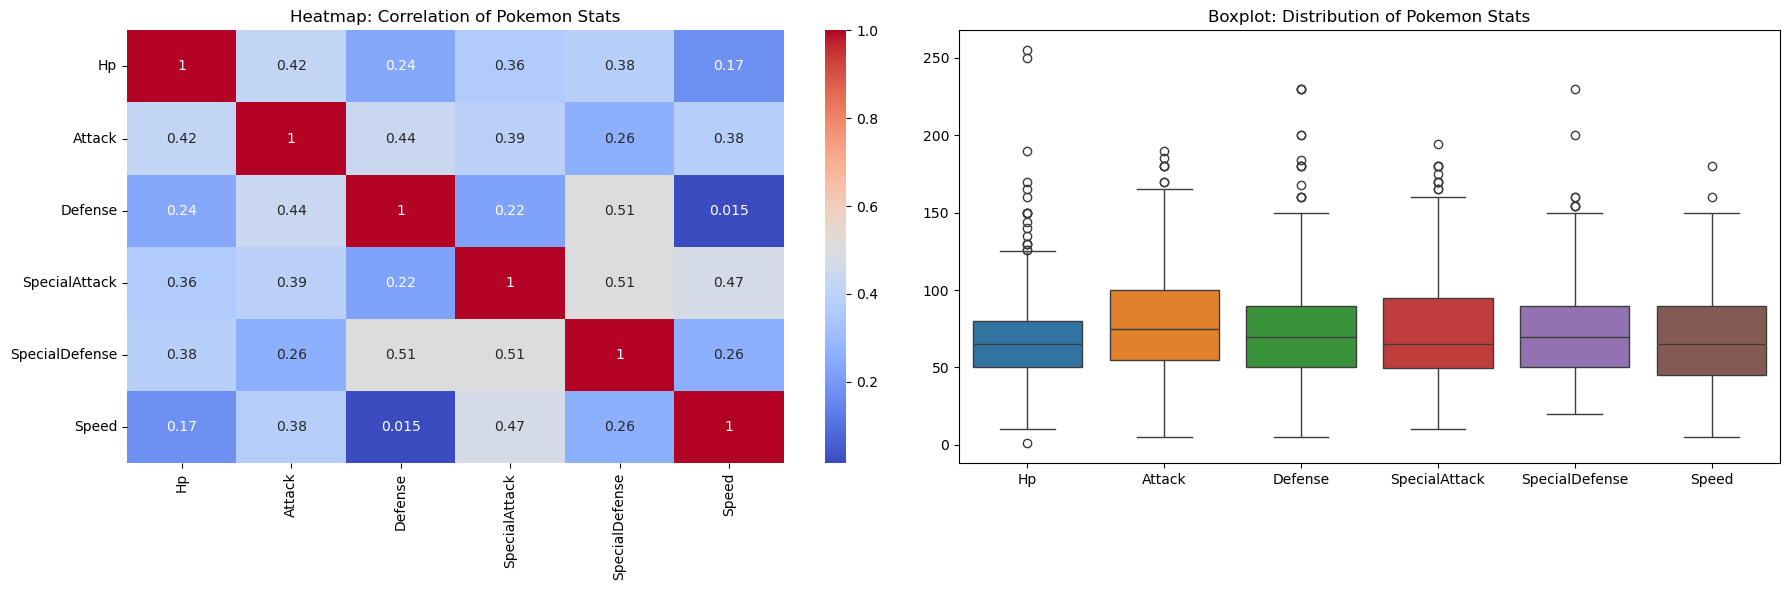

In [6]:

stats_cols = ['Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed']
pokemon_stats = pokedex[stats_cols]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

pokemon_corr = pokemon_stats.corr()
sns.heatmap(pokemon_corr, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Heatmap: Correlation of Pokemon Stats')

sns.boxplot(data=pokemon_stats, ax=axes[1])
axes[1].set_title('Boxplot: Distribution of Pokemon Stats')

plt.tight_layout()
plt.show()

In [7]:
merged_df = pd.merge(combats, pokedex, left_on='First_pokemon', right_on='ID', how='left')

# Đổi tên các cột của Pokemon 1 để tránh trùng lặp sau này
# Ví dụ: 'Name' -> 'Name_1', 'Hp' -> 'Hp_1'
cols_to_rename = {col: f"{col}_1" for col in pokedex.columns if col != 'ID'}
merged_df = merged_df.rename(columns=cols_to_rename)

# 3. Merge lần 2 cho Pokemon thứ hai
# left_on='Second_pokemon'
merged_df = pd.merge(merged_df, pokedex, left_on='Second_pokemon', right_on='ID', how='left')

# Đổi tên các cột của Pokemon 2
# Ví dụ: 'Name' -> 'Name_2', 'Hp' -> 'Hp_2'
cols_to_rename_2 = {col: f"{col}_2" for col in pokedex.columns if col != 'ID'}
merged_df = merged_df.rename(columns=cols_to_rename_2)
merged_df.head()

,First_pokemon,Second_pokemon,Winner,ID_x,Name_1,Type 1_1,Type 2_1,HiddenAbility_1,Generation_1,Hp_1,...,DamageFromFairy_2,Ability 1_2,Ability 2_2,NoGender_2,EggGroup1_2,EggGroup2_2,IsMega_2,FightsWon_2,TotalFights_2,WinPercentage_2
0,266,298,1,266,Larvitar,Rock,Ground,Sand Veil,2,50.0,...,2.0,Chlorophyll,Early Bird,0,Field,Grass,0,48,113,0.424779
1,702,701,1,702,Virizion,Grass,Fighting,NaN,5,91.0,...,2.0,Justified,NaN,1,No Eggs Discovered,No Eggs Discovered,0,105,123,0.853659
2,191,668,1,191,Togetic,Fairy,Flying,Super Luck,2,55.0,...,1.0,Telepathy,Synchronize,0,Human-Like,No Eggs Discovered,0,21,134,0.156716
3,237,683,1,237,Slugma,Fire,Fire,Weak Armor,2,40.0,...,2.0,Rough Skin,Sheer Force,0,Dragon,Monster,0,39,140,0.278571
4,151,231,0,151,Omastar,Rock,Water,Weak Armor,1,70.0,...,1.0,Sturdy,Gluttony,0,Bug,No Eggs Discovered,0,0,0,0.000000


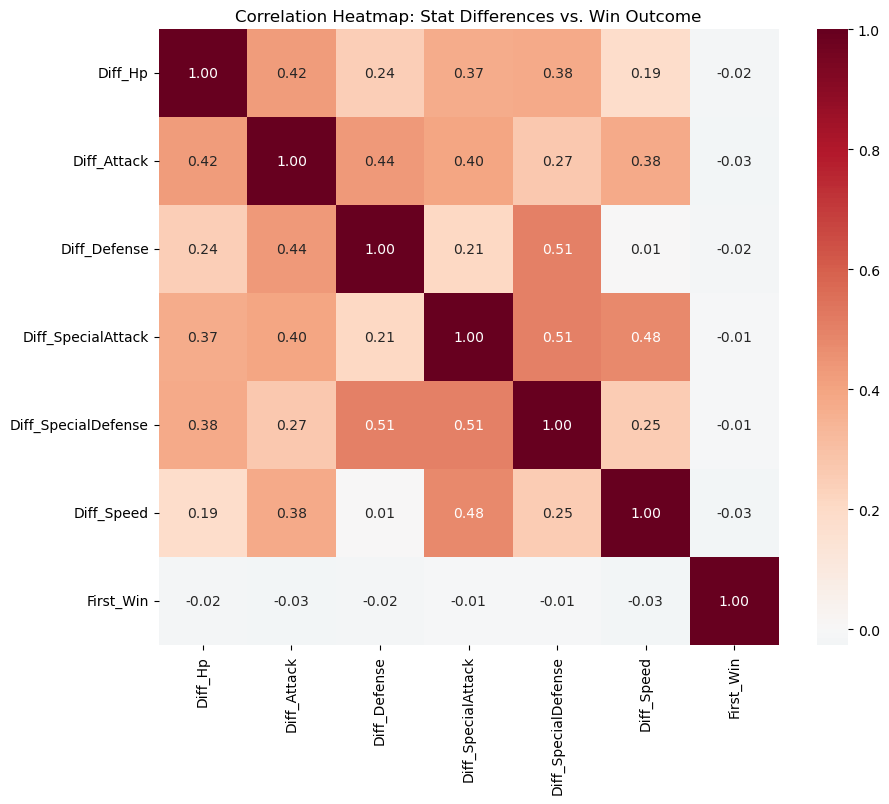

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

merged_df['First_Win'] = (merged_df['Winner'] == merged_df['First_pokemon']).astype(int)


stats_cols = ['Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed']
diff_cols = []

for col in stats_cols:
    merged_df[f'Diff_{col}'] = merged_df[f'{col}_1'] - merged_df[f'{col}_2']
    diff_cols.append(f'Diff_{col}')

cols_for_heatmap = diff_cols + ['First_Win']

plt.figure(figsize=(10, 8))
corr_diff = merged_df[cols_for_heatmap].corr()

sns.heatmap(corr_diff, 
            annot=True,       
            fmt=".2f",        
            cmap='RdBu_r',    
            center=0)         

plt.title('Correlation Heatmap: Stat Differences vs. Win Outcome')
plt.show()

In [9]:
df_compare = merged_df.dropna(subset=['Winner']).copy() 
df_compare['P1_won'] = df_compare['Winner'] == df_compare['First_pokemon']

# Initialize counters
leg_wins = 0
leg_total = 0
non_leg_wins = 0
non_leg_total = 0

# Check P1
leg_p1_mask = df_compare['IsLegendary_1'] == True  
leg_total += leg_p1_mask.sum()
leg_wins += (leg_p1_mask & df_compare['P1_won']).sum()

non_leg_p1_mask = df_compare['IsLegendary_1'] == False
non_leg_total += non_leg_p1_mask.sum()
non_leg_wins += (non_leg_p1_mask & df_compare['P1_won']).sum()

# Check P2
leg_p2_mask = df_compare['IsLegendary_2'] == True 
leg_total += leg_p2_mask.sum()
leg_wins += (leg_p2_mask & (~df_compare['P1_won'])).sum()

non_leg_p2_mask = df_compare['IsLegendary_2'] == False 
non_leg_total += non_leg_p2_mask.sum()
non_leg_wins += (non_leg_p2_mask & (~df_compare['P1_won'])).sum()

# Calculate rates
leg_winrate = leg_wins / leg_total if leg_total > 0 else 0
non_leg_winrate = non_leg_wins / non_leg_total if non_leg_total > 0 else 0

print(f"Legendary Winrate: {leg_winrate:.2%} ({leg_wins}/{leg_total})")
print(f"Non-Legendary Winrate: {non_leg_winrate:.2%} ({non_leg_wins}/{non_leg_total})")

Legendary Winrate: 50.16% (3197/6373)
Non-Legendary Winrate: 49.99% (46803/93627)


Quá trình này bắt đầu bằng việc loại bỏ các trận đấu không có kết quả (df.dropna(subset=['Winner'])), xử lý các dòng bị thiếu giá trị trong cột Winner để chỉ tính trên các trận đấu đã hoàn thành. Sau khi có bảng dữ liệu sạch (df_clean), chương trình xác định kết quả của từng trận đấu bằng cách tạo cột P1_won (True nếu Pokemon 1 thắng). Cuối cùng, code tiến hành phân loại và đếm: nó tạo ra các bộ lọc (mask) để tách riêng các trận đấu có sự tham gia của Pokemon Legendary và Non-Legendary (ở cả vị trí P1 và P2). Bằng cách sử dụng các bộ lọc này, chương trình cộng dồn tổng số trận đấu và tổng số trận thắng của từng loại Pokemon. Bước cuối cùng là chia tổng số trận thắng cho tổng số trận đấu (leg_wins / leg_total) để cho ra tỷ lệ thắng thực tế của từng nhóm.

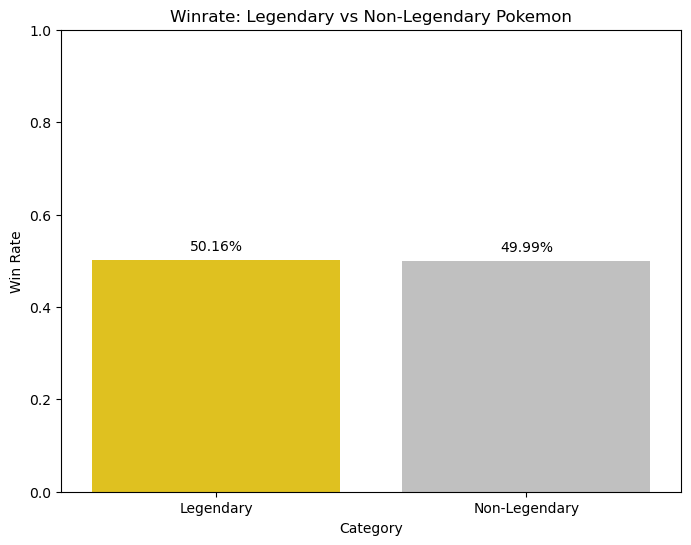

In [ ]:
# Prepare data for plotting
data = {
    'Category': ['Legendary', 'Non-Legendary'],
    'Winrate': [leg_winrate, non_leg_winrate]
}
winrate_df = pd.DataFrame(data)

# Create the bar chart
plt.figure(figsize=(8, 6))
barplot = sns.barplot(x='Category', y='Winrate', data=winrate_df, hue='Category', palette=['Gold', 'Silver'])

# Add title and labels
plt.title('Winrate: Legendary vs Non-Legendary Pokemon')
plt.ylabel('Win Rate')
plt.ylim(0, 1)  

for index, row in winrate_df.iterrows():
    barplot.text(index, row['Winrate'] + 0.02, f"{row['Winrate']:.2%}", color='black', ha="center")

plt.show()

Biểu đồ so sánh tỷ lệ thắng giữa Pokemon Huyền thoại (Legendary) và nhóm thường (Non-Legendary) cho thấy một kết quả cân bằng đến kinh ngạc, đi ngược lại với kỳ vọng thông thường về sức mạnh áp đảo của các Pokemon cấp cao. Cụ thể, tỷ lệ thắng của nhóm Legendary là 50.16%, chỉ nhỉnh hơn vỏn vẹn 0.17% so với mức 49.99% của nhóm Non-Legendary. Sự chênh lệch không đáng kể này cho thấy trong tập dữ liệu được phân tích, nhãn dán "Huyền thoại" không đóng vai trò quyết định đến kết quả trận đấu. Thay vào đó, các con số tiệm cận mức 50/50 gợi ý rằng các trận đấu diễn ra rất công bằng hoặc mang tính ngẫu nhiên cao, khiến cơ hội chiến thắng được chia đều cho cả hai phía bất chấp sự khác biệt về chỉ số sức mạnh lý thuyết.